# Accelerate Large Linear Programs using Distributed PDLP on Multi GPU

NVIDIA cuOpt solves very large Linear Programs (LP) very efficiently on GPU with its implementation of the first-order optimization method known as PDLP (primal-dual hybrid gradient method for LP). This technique can now be run on multi-GPU to further speed up the solution process and allow solving existing LPs faster or solving very large LPs that do not fit in a single GPU memory.

<b>Prerequisite</b>: to run cuOpt PDLP solver on multi-GPU, the node where this notebook is running must have >1 gpus available.

Let's start by cloning the cuOpt repository and making it ready to run PDLP on multi-GPU

In [1]:
!git clone https://github.com/NVIDIA/cuopt.git
%cd cuopt

Cloning into 'cuopt'...
remote: Enumerating objects: 37925, done.
remote: Counting objects: 100% (2369/2369), done.
remote: Compressing objects: 100% (963/963), done.
remote: Total 37925 (delta 1897), reused 1428 (delta 1403), pack-reused 35556 (from 3)
Receiving objects: 100% (37925/37925), 45.02 MiB | 28.94 MiB/s, done.
Resolving deltas: 100% (28318/28318), done.
/home/ubuntu/cuopt


Now we create `cuopt_env`, a conda environment to allow cuopt to run. This can take a few minutes.

In [2]:
!curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj bin/micromamba
!./bin/micromamba create -r ~/micromamba -n cuopt_env -y -f conda/environments/all_cuda-133_arch-x86_64.yaml
!./bin/micromamba run -r ~/micromamba -n cuopt_env python -m pip install --upgrade matplotlib

bin/micromamba
[+] 0.0s
[+] 0.1s
rapidsai-nightly/linux-64 (check zst)    ━╸━━━━━━━━━━━━━━   0.0 B Checking  0.1s
rapidsai-nightly/linux-64 (check shards) ━━━╸━━━━━━━━━━━━   0.0 B Checking  0.0s
rapidsai-nightly/noarch (check zst)      ━━━╸━━━━━━━━━━━━   0.0 B Checking  0.0s
rapidsai-nightly/noarch (check shards)   ━━━━━━━╸━━━━━━━━   0.0 B Checking  0.0s
rapidsai/linux-64 (check zst)            ━━━╸━━━━━━━━━━━━   0.0 B Checking  0.0s[+] 0.2s
rapidsai-nightly/linux-64 (check zst)    ━━╸━━━━━━━━━━━━━   0.0 B Checking  0.2s
rapidsai-nightly/linux-64 (check shards) ━━━╸━━━━━━━━━━━━   0.0 B Checking  0.1s
rapidsai-nightly/noarch (check zst)      ━━━━╸━━━━━━━━━━━   0.0 B Checking  0.1s
rapidsai-nightly/noarch (check shards)   ━━━━━━━╸━━━━━━━━   0.0 B Checking  0.1s
rapidsai/linux-64 (check zst)            ━━━╸━━━━━━━━━━━━   0.0 B Checking  0.1s[+] 0.3s
rapidsai-nightly/noarch (check zst)    ━━━━━━━━╸━━━━━━━━━   0.0 B Checking  0.2s
rapidsai-nightly/noarch (check shards) ━━━━━━━━━╸━━━━━━━━   

Building the cuOpt solver :

In [3]:
!./bin/micromamba run -r ~/micromamba -n cuopt_env \
    ./build.sh libcuopt      \
    --skip-c-python-adapters \
    --skip-fatbin-write      \
    --skip-tests-build

Building for the architecture of the GPU in the system...
CMake Warning (author) at /home/ubuntu/micromamba/envs/cuopt_env/share/cmake-4.4/Modules/GNUInstallDirs.cmake:448 (message):
  Unable to determine default CMAKE_INSTALL_LIBDIR directory because no
  target architecture is known.  Please enable at least one language before
  including GNUInstallDirs.
Call Stack (most recent call first):
  /home/ubuntu/micromamba/envs/cuopt_env/share/cmake-4.4/Modules/GNUInstallDirs.cmake:301 (_GNUInstallDirs_LIBDIR_get_default)
  /home/ubuntu/micromamba/envs/cuopt_env/share/cmake-4.4/Modules/GNUInstallDirs.cmake:301 (cmake_language)
  /home/ubuntu/micromamba/envs/cuopt_env/share/cmake-4.4/Modules/GNUInstallDirs.cmake:547 (_GNUInstallDirs_cache_path)
  CMakeLists.txt:11 (include)
This warning is for project developers.  Use -Wno-author to suppress it.

-- Fetching rapids-cmake from https://github.com/rapidsai/rapids-cmake/archive/refs/heads/release/26.10.zip
-- CMAKE_MODULE_PATH = /home/ubuntu/cuo

Now let's ensure we can solve a basic instance (`afiro_original`) using the **PDLP** agorithm (by setting `method 1`). It is this algorithm (PDLP) that is now accelerated on multiple GPUs.

In [4]:
!./cpp/build/cuopt_cli datasets/linear_programming/afiro_original.mps \
    --method 1

Reading file afiro_original.mps
Read file afiro_original.mps in 0.00 seconds
cuOpt version: 26.10.0, git hash: 39900e6b, host arch: x86_64, device archs: 90a-real
CPU: Intel(R) Xeon(R) Platinum 8480+, threads: 112C/112T, RAM usage: 15.51/944.84GiB
CPU SIMD target: AVX-512
CUDA 13.3, device: NVIDIA H100 80GB HBM3 (ID 0), VRAM: 79.18 GiB
CUDA device UUID: b77ebbc3-92d3-18ba-6a6e-6dd62370a02d
Solving a problem with 27 constraints, 32 variables (0 integers), and 83 nonzeros
Problem scaling:
Objective coefficents range:          [3e-01, 1e+01]
Constraint matrix coefficients range: [1e-01, 2e+00]
Constraint rhs / bounds range:        [0e+00, 5e+02]
Variable bounds range:                [0e+00, 0e+00]

Using PSLP presolver
PSLP Presolved problem: 14 constraints, 18 variables, 40 non-zeros
PSLP presolve time: 0.06s
Objective offset 0.000000 scaling_factor 1.000000
   Iter    Primal Obj.      Dual Obj.    Gap        Primal Res.  Dual Res.   Time
      0 +0.00000000e+00 +0.00000000e+00  0.00e+00

We now build a simple helper to run the solver, parse the log and return the time result.

In [5]:
import re
import subprocess

# Each successful solve appends {"instance", "num_gpus", "time_s"}.
solve_times = []


def run_cuopt(mps_path, *extra_args, num_gpus=None):
    cmd = [
        "./cpp/build/cuopt_cli", mps_path, "--method", "1",
        "--relative-primal-tolerance", "1e-6",
        "--relative-dual-tolerance", "1e-6",
        "--relative-gap-tolerance", "1e-6",
        "--mps-reader", "experimental-fast",
        "--pdlp-hyper-enable-curtis-reid-scaling", "false",
        *extra_args,
    ]

    if num_gpus is not None:
        cmd += ["--num-gpus", str(num_gpus)]

    print(
        f"\nRunning {mps_path} with "
        f"{num_gpus if num_gpus is not None else 1} GPUs\n"
    )

    process = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    log_lines = []

    for line in process.stdout:
        print(line, end="", flush=True)
        log_lines.append(line)

    process.wait()
    log = "".join(log_lines)

    match = re.search(r"^Status:.*Time:\s*([0-9.]+)s", log, re.M)

    if match is None:
        raise RuntimeError(
            f"No solver Time in cuopt_cli output (exit code {process.returncode})"
        )

    time_s = float(match.group(1))

    solve_times.append({
        "instance": mps_path.rsplit("/", 1)[-1],
        "num_gpus": num_gpus,
        "time_s": time_s,
    })

    return time_s


In [6]:
t_afiro = run_cuopt("datasets/linear_programming/afiro_original.mps")


Running datasets/linear_programming/afiro_original.mps with 1 GPUs

Reading file afiro_original.mps
Read file afiro_original.mps in 0.01 seconds
cuOpt version: 26.10.0, git hash: 39900e6b, host arch: x86_64, device archs: 90a-real
CPU: Intel(R) Xeon(R) Platinum 8480+, threads: 112C/112T, RAM usage: 13.93/944.84GiB
CPU SIMD target: AVX-512
CUDA 13.3, device: NVIDIA H100 80GB HBM3 (ID 0), VRAM: 79.18 GiB
CUDA device UUID: b77ebbc3-92d3-18ba-6a6e-6dd62370a02d
Solving a problem with 27 constraints, 32 variables (0 integers), and 83 nonzeros
Problem scaling:
Objective coefficents range:          [3e-01, 1e+01]
Constraint matrix coefficients range: [1e-01, 2e+00]
Constraint rhs / bounds range:        [0e+00, 5e+02]
Variable bounds range:                [0e+00, 0e+00]

Using PSLP presolver
PSLP Presolved problem: 14 constraints, 18 variables, 40 non-zeros
PSLP presolve time: 0.06s
Objective offset 0.000000 scaling_factor 1.000000
   Iter    Primal Obj.      Dual Obj.    Gap        Primal Res

In [7]:
print(f"Extracted afiro solve time: {t_afiro}s")

Extracted afiro solve time: 0.18s


## Solving with Multi-GPU PDLP

Let's try again to solve `afiro_original`, but this time with 4 gpus, using the parameter `--num-gpus 4`

In [8]:
t_afiro_4_GPU = run_cuopt("datasets/linear_programming/afiro_original.mps", num_gpus=4)

print(f"\n\nExtracted afiro solve time: {t_afiro_4_GPU}")


Running datasets/linear_programming/afiro_original.mps with 4 GPUs

Reading file afiro_original.mps
Read file afiro_original.mps in 0.01 seconds
cuOpt version: 26.10.0, git hash: 39900e6b, host arch: x86_64, device archs: 90a-real
CPU: Intel(R) Xeon(R) Platinum 8480+, threads: 112C/112T, RAM usage: 13.04/944.84GiB
CPU SIMD target: AVX-512
CUDA 13.3, device: NVIDIA H100 80GB HBM3 (ID 0), VRAM: 79.18 GiB
CUDA device UUID: b77ebbc3-92d3-18ba-6a6e-6dd62370a02d
CUDA 13.3, device: NVIDIA H100 80GB HBM3 (ID 1), VRAM: 79.18 GiB
CUDA device UUID: 3a89376c-4725-27b5-8b5e-df85e4c64b97
CUDA 13.3, device: NVIDIA H100 80GB HBM3 (ID 2), VRAM: 79.18 GiB
CUDA device UUID: fc4cbfd7-a637-2465-62ce-b80f4e877808
CUDA 13.3, device: NVIDIA H100 80GB HBM3 (ID 3), VRAM: 79.18 GiB
CUDA device UUID: aabf7a3b-1b2e-005b-2527-4cb21ad63be2
CUDA 13.3, device: NVIDIA H100 80GB HBM3 (ID 4), VRAM: 79.18 GiB
CUDA device UUID: b9904e28-8ae9-62d7-a738-6fc9fc7ca293
CUDA 13.3, device: NVIDIA H100 80GB HBM3 (ID 5), VRAM: 79.

We don't see much speedup between 1 GPU solve and 4 GPU solve on `afiro_original`. This is due to the small size of this instance.

Now we download zib03, a large-scale LP problem 

In [9]:
!wget -P datasets/linear_programming/  https://miplib2010.zib.de/contrib/miplib2003-contrib/IPWS2008/zib03.mps.gz
!gunzip datasets/linear_programming/zib03.mps.gz

--2026-09-23 14:25:05--  https://miplib2010.zib.de/contrib/miplib2003-contrib/IPWS2008/zib03.mps.gz
Resolving miplib2010.zib.de (miplib2010.zib.de)... 130.73.131.233
Connecting to miplib2010.zib.de (miplib2010.zib.de)|130.73.131.233|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 649776384 (620M) [application/x-gzip]
Saving to: ‘datasets/linear_programming/zib03.mps.gz’

zib03.mps.gz        100%[===================>] 619.67M  21.0MB/s    in 24s     

2026-09-23 14:25:29 (26.2 MB/s) - ‘datasets/linear_programming/zib03.mps.gz’ saved [649776384/649776384]



And this larger instance can now be solved on 1, 2, 4 and 8 GPUs with the parameter `--num_gpus`

In [10]:
t_zib03_1_gpu = run_cuopt(
    "datasets/linear_programming/zib03.mps",
    num_gpus=1,
)
t_zib03_1_gpu


Running datasets/linear_programming/zib03.mps with 1 GPUs

Reading file zib03.mps
Read file zib03.mps in 3.85 seconds
cuOpt version: 26.10.0, git hash: 39900e6b, host arch: x86_64, device archs: 90a-real
CPU: Intel(R) Xeon(R) Platinum 8480+, threads: 112C/112T, RAM usage: 15.69/944.84GiB
CPU SIMD target: AVX-512
CUDA 13.3, device: NVIDIA H100 80GB HBM3 (ID 0), VRAM: 79.18 GiB
CUDA device UUID: b77ebbc3-92d3-18ba-6a6e-6dd62370a02d
Solving a problem with 19731970 constraints, 29128799 variables (0 integers), and 104422573 nonzeros
Problem scaling:
Objective coefficents range:          [1e+00, 2e+00]
Constraint matrix coefficients range: [1e+00, 1e+00]
Constraint rhs / bounds range:        [1e+00, 1e+00]
Variable bounds range:                [0e+00, 1e+00]

Using PSLP presolver
PSLP Presolved problem: 19731970 constraints, 29128799 variables, 104422573 non-zeros
PSLP presolve time: 21.04s
Objective offset 0.000000 scaling_factor 1.000000
   Iter    Primal Obj.      Dual Obj.    Gap      

349.237

In [11]:
t_zib03_2gpu = run_cuopt(
    "datasets/linear_programming/zib03.mps",
    num_gpus=2,
)
t_zib03_4gpu = run_cuopt(
    "datasets/linear_programming/zib03.mps",
    num_gpus=4,
)
t_zib03_8gpu = run_cuopt(
    "datasets/linear_programming/zib03.mps",
    num_gpus=8,
)


Running datasets/linear_programming/zib03.mps with 2 GPUs

Reading file zib03.mps
Read file zib03.mps in 3.88 seconds
cuOpt version: 26.10.0, git hash: 39900e6b, host arch: x86_64, device archs: 90a-real
CPU: Intel(R) Xeon(R) Platinum 8480+, threads: 112C/112T, RAM usage: 16.08/944.84GiB
CPU SIMD target: AVX-512
CUDA 13.3, device: NVIDIA H100 80GB HBM3 (ID 0), VRAM: 79.18 GiB
CUDA device UUID: b77ebbc3-92d3-18ba-6a6e-6dd62370a02d
CUDA 13.3, device: NVIDIA H100 80GB HBM3 (ID 1), VRAM: 79.18 GiB
CUDA device UUID: 3a89376c-4725-27b5-8b5e-df85e4c64b97
CUDA 13.3, device: NVIDIA H100 80GB HBM3 (ID 2), VRAM: 79.18 GiB
CUDA device UUID: fc4cbfd7-a637-2465-62ce-b80f4e877808
CUDA 13.3, device: NVIDIA H100 80GB HBM3 (ID 3), VRAM: 79.18 GiB
CUDA device UUID: aabf7a3b-1b2e-005b-2527-4cb21ad63be2
CUDA 13.3, device: NVIDIA H100 80GB HBM3 (ID 4), VRAM: 79.18 GiB
CUDA device UUID: b9904e28-8ae9-62d7-a738-6fc9fc7ca293
CUDA 13.3, device: NVIDIA H100 80GB HBM3 (ID 5), VRAM: 79.18 GiB
CUDA device UUID: 7c

And now let's take a look at the solve times and compare the PDLP solver performance over multiple GPUs.

In [12]:
print(f"1 GPU : {t_zib03_1_gpu}s")
print(f"2 GPUs: {t_zib03_2gpu}s")
print(f"4 GPUs: {t_zib03_4gpu}s")
print(f"8 GPUs: {t_zib03_8gpu}s")

1 GPU : 349.237s
2 GPUs: 203.815s
4 GPUs: 128.706s
8 GPUs: 90.637s


In [ ]:
import sys
!{sys.executable} -m ensurepip --upgrade
!{sys.executable} -m pip install -q matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [21]:
import matplotlib.pyplot as plt

def plot_gpu_times(instance):
    instance_name = f"{instance}.mps"
    # Convert None to 1 GPU
    for r in solve_times:
        if r["num_gpus"] is None:
            r["num_gpus"] = 1

    # Filter and sort
    rows = sorted(
        [r for r in solve_times if r["instance"] == instance_name],
        key=lambda r: r["num_gpus"]
    )

    if not rows:
        print(f"No data found for {instance_name}")
        return

    gpus = [r["num_gpus"] for r in rows]
    times = [r["time_s"] for r in rows]

    plt.figure(figsize=(8, 5))
    plt.title(f"PDLP Solve Time for {instance}")
    bars = plt.bar(
        range(len(gpus)),
        times,
        color="#76B900",
        width=0.5
    )

    plt.xlabel("Number of GPUs")
    plt.ylabel("Solve time (s)")
    plt.xticks(range(len(gpus)), gpus)

    for bar, time in zip(bars, times):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            time,
            f"{time:.2f}s",
            ha="center",
            va="bottom",
        )

    plt.show()

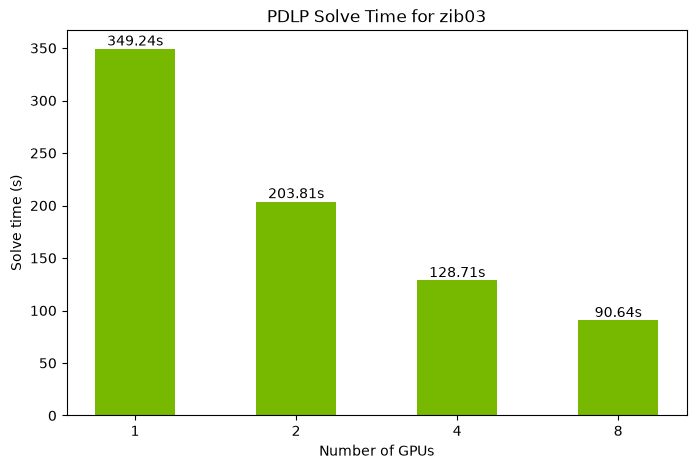

In [22]:
plot_gpu_times("zib03")

Feel free to upload your own LP files to test multi-GPU PDLP and share with us your experience!

In [16]:
path = "path/to/your/lp/file.mps"
run_cuopt(path, num_gpus=1)
run_cuopt(path, num_gpus=8)

plot_gpu_times(path.rsplit("/", 1)[-1])


Running path/to/your/lp/file.mps with 1 GPUs

Reading file file.mps
Parser exception: {"MPS_PARSER_ERROR_TYPE": "RuntimeError", "msg": "Failed to open raw MPS file 'path/to/your/lp/file.mps': No such file or directory"}
Parsing input file failed. Exiting!


RuntimeError: No solver Time in cuopt_cli output (exit code 255)